<a href="https://colab.research.google.com/github/ramimrad01/A2-SYSC4415/blob/main/W2026/Assignments/A2/A2_SYSC4415_W26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 W26 Assignment 2 – Fire Hydrant Detection 🚒

Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [3]:
# Import all the necessary libraries here

import pandas as pd
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Mount Google Drive and unzip the dataset.

In [4]:
## Code provided by TA. DO NOT CHANGE THIS CELL

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

Mounted at /content/drive
Archive:  /content/drive/MyDrive/FH_detection_data.zip
   creating: /content/train/
 extracting: /content/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg  
 extracting: /content/train/100_PNG.rf.d52fbff94c483761d0644a1e8abe4c95.jpg  
 extracting: /content/train/101_PNG.rf.f1335e18f815c8c8044a94c09db7f025.jpg  
 extracting: /content/train/102378468_d8132a415b_z_jpg.rf.6bc008d0d532d3365f580b7aaa7623e3.jpg  
 extracting: /content/train/102_PNG.rf.160c945e0881c92a078a14069d9a6b9a.jpg  
 extracting: /content/train/102_jpg.rf.17df75e9dda0f851c9f5e1d554f07488.jpg  
 extracting: /content/train/103357395_388d701e12_z_jpg.rf.a54c985e93402af49ba422f005e702d8.jpg  
 extracting: /content/train/103_jpg.rf.a649213f3998906bf2298607f82ee839.jpg  
 extracting: /content/train/104351403_25e959f878_z_jpg.rf.43156bd0a74313df69967d88e5e6a268.jpg  
 extracting: /content/train/104_PNG.rf.c14671a6a52ae05f9ae2bf1df7e4316e.jpg  
 extracting: /content/train/104_

----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ Checking for class imbalance is important because a model trained on imbalanced data will be biased toward the majority class. In this case, since most images contain no fire hydrant, a simpler model could achieve high accuracy by always predicting 0 or "No Hydrant". This inflates the accuracy and hides the fact that the model may be failing entirely at detecting the minority class (fire hydrants). Thia can cause the model to minimise loss by favouring the larger class, resulting in poor recall on hydrant images. Therefore, before training, we need to either reweight the loss, oversample the minority class, or at minimum choose evaluation metrics (like recall) that expose this issue.


Train label columns: ['filename', 'Fire Hydrants']
Train label sample:
                                             filename  Fire Hydrants
0  45-394823_-75-62419684_heading270_jpg.rf.01200...              0
1  53-4733_-113-44139_heading180_jpg.rf.00a4904dd...              0
2     49_jpg.rf.00d3bdf822d633cc6d6fe5ed2c248a59.jpg              1
3  download_jpeg_jpg.rf.00666bac2a7d67fe8f26db4a7...              1
4  45-42126683_-75-64919699_heading270_jpg.rf.02d...              1

Train set size:      2272
Validation set size: 563

Normalised train columns: ['filename', 'label']
                                            filename  label
0  45-394823_-75-62419684_heading270_jpg.rf.01200...      0
1  53-4733_-113-44139_heading180_jpg.rf.00a4904dd...      0
2     49_jpg.rf.00d3bdf822d633cc6d6fe5ed2c248a59.jpg      1
3  download_jpeg_jpg.rf.00666bac2a7d67fe8f26db4a7...      1
4  45-42126683_-75-64919699_heading270_jpg.rf.02d...      1


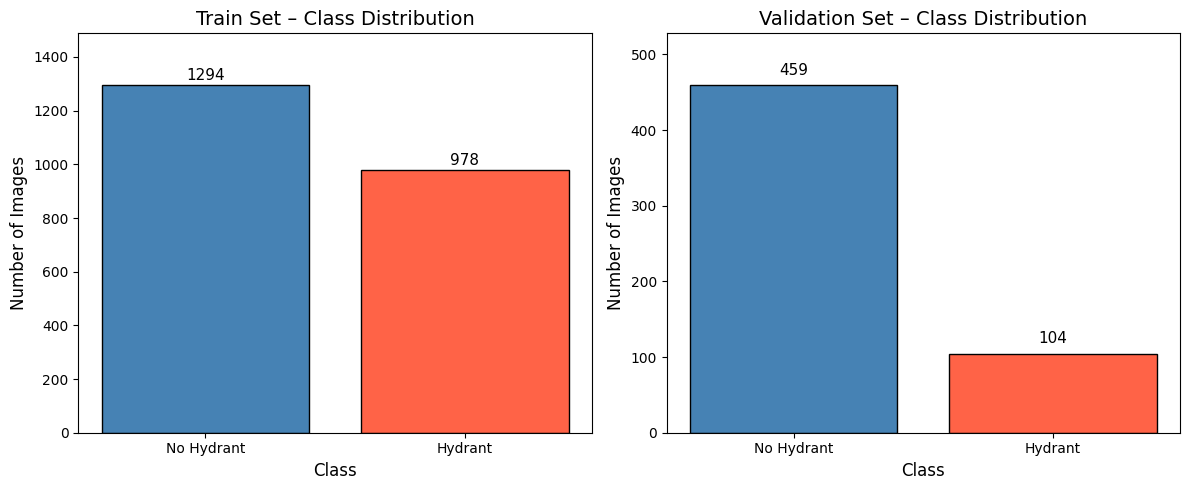

Train class counts:
 label
No Hydrant    1294
Hydrant        978
Name: count, dtype: int64

Validation class counts:
 label
No Hydrant    459
Hydrant       104
Name: count, dtype: int64


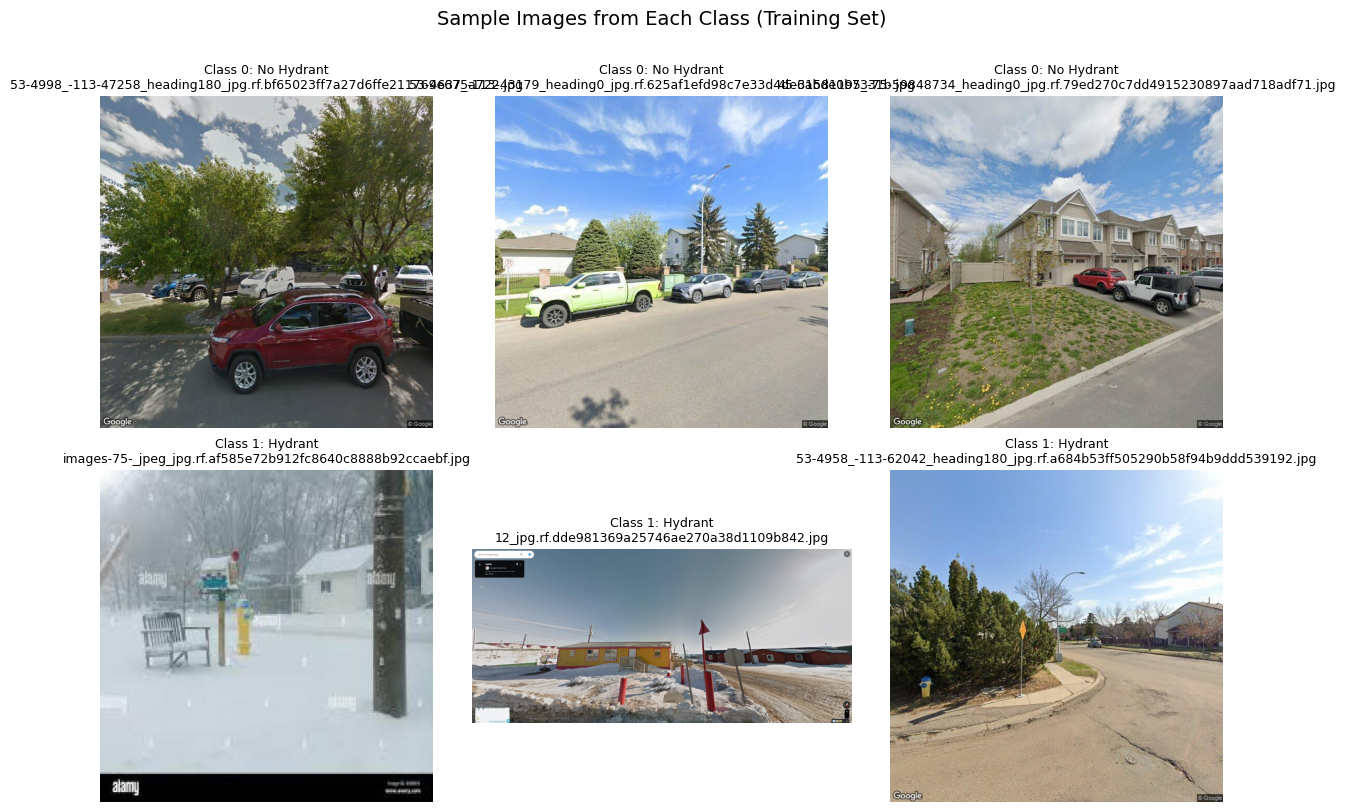

In [5]:
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

# Stripping any extra whitespace from column names
train_label.columns = train_label.columns.str.strip()
valid_label.columns = valid_label.columns.str.strip()

print("Train label columns:", train_label.columns.tolist())
print("Train label sample:\n", train_label.head())
print(f"\nTrain set size:      {len(train_label)}")
print(f"Validation set size: {len(valid_label)}")


# Identify the filename and label column names
# The CSV is expected to have 'filename' and one of 'fire hydrant' / 'label' etc.
# We normalise to 'filename' and 'label'
# I decided to rename/normalize the colomns in the csv file from "filename" and "Fire Hydrants" to "filename" and "label"
def normalise_df(df):
    df = df.copy()
    # Find the label column (non-filename column)
    col_map = {}
    for c in df.columns:
        cl = c.lower().strip()
        if cl in ("filename", "file", "image"):
            col_map[c] = "filename"
        else:
            col_map[c] = "label"
    df.rename(columns=col_map, inplace=True)
    return df

train_df = normalise_df(train_label)
valid_df = normalise_df(valid_label)

print("\nNormalised train columns:", train_df.columns.tolist())
print(train_df.head())


#Labeling label values
label_names = {0: "No Hydrant", 1: "Hydrant"}

# Visualizing the data/class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, split in zip(axes, [train_df, valid_df], ["Train", "Validation"]):
    counts = df["label"].value_counts().sort_index()
    bars = ax.bar([label_names[i] for i in counts.index],
                  counts.values,
                  color=["steelblue", "tomato"],
                  edgecolor="black")
    ax.set_title(f"{split} Set – Class Distribution", fontsize=14)
    ax.set_xlabel("Class", fontsize=12)
    ax.set_ylabel("Number of Images", fontsize=12)
    ax.set_ylim(0, counts.max() * 1.15)
    # Annotate bars with counts
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                str(val), ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=100)
plt.show()
print("Train class counts:\n", train_df["label"].value_counts().rename(label_names))
print("\nValidation class counts:\n", valid_df["label"].value_counts().rename(label_names))



def show_samples(df, data_path, n=3):
    """Display n sample images from each class side-by-side."""
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    for class_id, class_name in label_names.items():
        subset = df[df["label"] == class_id].sample(n, random_state=42)
        for col, (_, row) in enumerate(subset.iterrows()):
            img_path = os.path.join(data_path, row["filename"])
            img = mpimg.imread(img_path)
            ax = axes[class_id][col]
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"Class {class_id}: {class_name}\n{row['filename']}", fontsize=9)
    plt.suptitle("Sample Images from Each Class (Training Set)", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=100, bbox_inches="tight")
    plt.show()

show_samples(train_df, train_data_path)

---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ One-hot encoding is not necessary for binary classification, as in a problem with 2 classes, the label is a single scalar 0 or 1. The single neuron which is the output of the network produces a probability between 0 and 1. One-hot encoding would produce a two-element vector while BCELoss in PyTorch expects a scalar format. There for, if we use one-hot encoding, we would require changing the loss function an output layer unnecessarily.

In [6]:
# Resizing image to 128x128
# Training: resize, random horizontal flip (data augmentation), convert to tensor, normalise
# Validation: resize, convert to tensor, normalise (no augmentation, evaluate as-is)
IMG_SIZE = 128
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# Dataset setup
class HydrantDataset(Dataset):
    """PyTorch Dataset for the fire hydrant classification."""

    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["filename"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row["label"], dtype=torch.float32)
        return image, label

# Creating dataset and loaders
train_dataset = HydrantDataset(train_df, "/content/train", transform=train_transform)
valid_dataset = HydrantDataset(valid_df, "/content/valid", transform=valid_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(valid_dataset)}")
print(f"Train batches:      {len(train_loader)}")
print(f"Valid batches:      {len(valid_loader)}")

Training samples:   2272
Validation samples: 563
Train batches:      71
Valid batches:      18


---

### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅
1. Adding dropout: Reduces overfitting. Dropout randomly zeroes a fraction of neurons during training, preventing co-adaptation and acting as an implicit ensemble of many sub-networks, which tends to improve generalisation on unseen data.  
2. Adding batch normalisation: Stabilizes and accelerates training. BatchNorm normalises the activations of each mini-batch, allowing for higher learning rates.  
3. Increasing the number of convolutional layers: Allows the network to learn more abstract hierarchical features. Two layers may capture only low-level edges and textures; deeper networks with three or more conv layers can learn object-level features, improving the detection of the difference between hydrant and non-hydrant images (assuming no overfitting).


In [8]:
class BaselineCNN(nn.Module):
    """
    Baseline CNN for binary fire hydrant classification.
    Architecture:
        Conv2d(3, 32, 3, padding=1) → ReLU → MaxPool2d(2, 2)
        Conv2d(32, 64, 3, padding=1) → ReLU → MaxPool2d(2, 2)
        Flatten
        Linear(64 * 32 * 32, 128) → ReLU
        Linear(128, 1) → Sigmoid
    """
    def __init__(self):
        super(BaselineCNN, self).__init__()
        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        # Second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        # Fully connected layers
        # After two 2×2 max-pools on a 128×128 input: 128/2/2 = 32
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)

        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

# quick check
model_baseline = BaselineCNN().to(device)
dummy = torch.randn(4, 3, 128, 128).to(device)
out = model_baseline(dummy)
print("Baseline CNN output shape:", out.shape)
print(model_baseline)

Baseline CNN output shape: torch.Size([4, 1])
BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ Recall is the most suitable evaluation metric for this case, since failing to detect a fire hydrant that is actually present (false negative) is a critical safety error. If an obstructed fire hydrant is not reported, it could potentially delay fire-suppression. Missing a hydrant (low recall) is far worse than a false alarm (low precision). With that being said, the F1-score is a practical overall metric because our dataset is imbalanced. Accuracy would be misleadingly high if the model simply predicts "No Hydrant" for everything. F1 balances precision and recall into a single number and is robust to class imbalance.


Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ A confusion matrix is a tabular summary used to evaluate the performance of a supervised machine learning classification model. It specifically indicates the amount of true negatives, false positives, false negatives and true positives. The confusion matrix is a simple 2×2 scoreboard:  
- Top-left (True Negative): Photos without a hydrant that the model correctly called "No Hydrant".
- Top-right (False Positive): Photos without a hydrant that the model wrongly called "Hydrant", aka a false alarm.  
- Bottom-left (False Negative): Photos with a hydrant that the model missed (this is dangerous).  
- Bottom-right (True Positive): Photos with a hydrant that the model correctly found.
Recall answers "Of all the real hydrants, how many did we actually find?". It is calculated as True Positives ÷ (True Positives + False Negatives). A high recall means few hydrants were missed, which is exactly what we need for safety.

Training Baseline CNN …
  Epoch 01/10  Train Loss: 0.2486  Val Loss: 0.7642
  Epoch 02/10  Train Loss: 0.1942  Val Loss: 0.8650
  Epoch 03/10  Train Loss: 0.1749  Val Loss: 0.9336
  Epoch 04/10  Train Loss: 0.1279  Val Loss: 1.1820
  Epoch 05/10  Train Loss: 0.1152  Val Loss: 1.0447
  Epoch 06/10  Train Loss: 0.1101  Val Loss: 1.6294
  Epoch 07/10  Train Loss: 0.1216  Val Loss: 1.2821
  Epoch 08/10  Train Loss: 0.1056  Val Loss: 3.2042
  Epoch 09/10  Train Loss: 0.0933  Val Loss: 1.7632
  Epoch 10/10  Train Loss: 0.0964  Val Loss: 2.0685


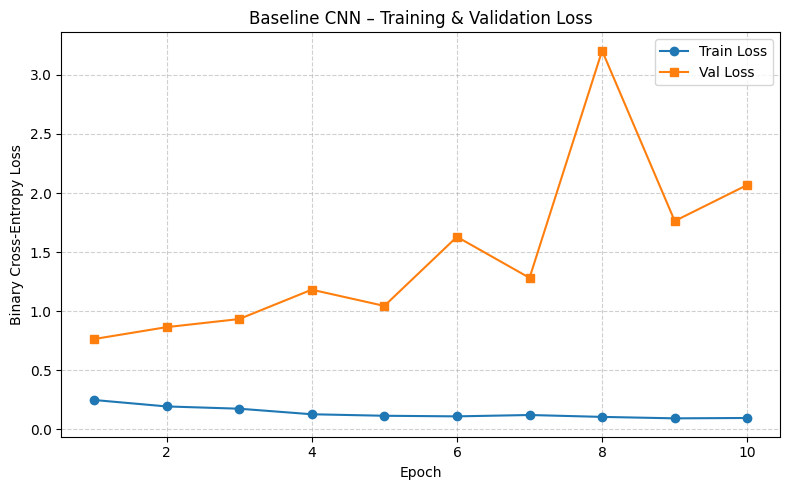


  Baseline CNN – Validation Metrics
              precision    recall  f1-score   support

  No Hydrant     0.9165    0.7887    0.8478       459
     Hydrant     0.4226    0.6827    0.5221       104

    accuracy                         0.7691       563
   macro avg     0.6695    0.7357    0.6849       563
weighted avg     0.8252    0.7691    0.7876       563



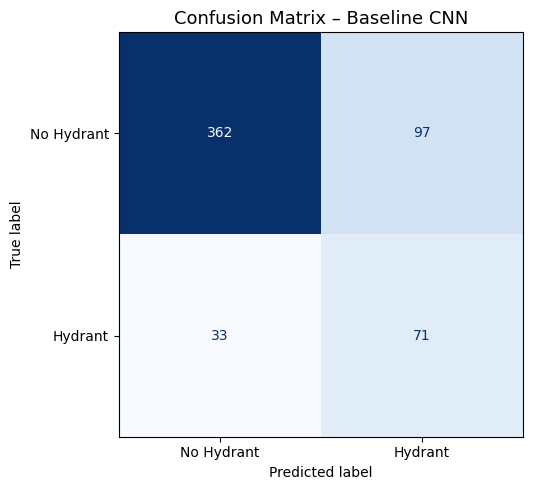

In [11]:
# Helper functions
def train_one_epoch(model, loader, criterion, optimiser):
    """Run one training epoch; return average loss."""
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)   # (B,) → (B,1)

        optimiser.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, threshold=0.5):
    """Evaluate model; return avg loss + all predictions and ground-truth labels."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels_dev = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels_dev)
            total_loss += loss.item() * images.size(0)

            preds = (outputs.squeeze(1) >= threshold).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.long().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)

def report_metrics(preds, labels, model_name="Model"):
    """Print classification report and display confusion matrix."""
    print(f"\n{'='*50}")
    print(f"  {model_name} – Validation Metrics")
    print(f"{'='*50}")
    print(classification_report(labels, preds,
                                 target_names=["No Hydrant", "Hydrant"],
                                 digits=4))

    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Hydrant", "Hydrant"])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix – {model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"cm_{model_name.replace(' ', '_')}.png", dpi=100)
    plt.show()

    return {
        "model":     model_name,
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0),
    }


# Training the baseline CNN
EPOCHS   = 10
LR       = 0.001

criterion_base = nn.BCELoss()
optimiser_base = optim.Adam(model_baseline.parameters(), lr=LR)

train_losses_base, valid_losses_base = [], []

print("Training Baseline CNN …")
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model_baseline, train_loader,
                               criterion_base, optimiser_base)
    vl_loss, _, _ = evaluate(model_baseline, valid_loader, criterion_base)
    train_losses_base.append(tr_loss)
    valid_losses_base.append(vl_loss)
    print(f"  Epoch {epoch:02d}/{EPOCHS}  Train Loss: {tr_loss:.4f}  Val Loss: {vl_loss:.4f}")


# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, EPOCHS + 1), train_losses_base, label="Train Loss", marker="o")
ax.plot(range(1, EPOCHS + 1), valid_losses_base, label="Val Loss",   marker="s")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Baseline CNN – Training & Validation Loss")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("loss_curve_baseline.png", dpi=100)
plt.show()

# Evaluating the baseline CNN on the validation set
_, preds_base, labels_base = evaluate(model_baseline, valid_loader, criterion_base)
results_base = report_metrics(preds_base, labels_base, "Baseline CNN")
all_results = [results_base]   # collecting results for final comparison

---


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ Your answer here

In [14]:
## Enter your code here..

---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ Your answer here

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅ Your answer here


In [ ]:
## Enter your code here..

---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ Your answer here..


-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ Your answer here..


---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

